Initializing Bit Wave Evaluation Engine...
Loading Neural Weights...
🧠 Performing Batch Inference...


/Users/shunkhwn/Library/Python/3.9/lib/python/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


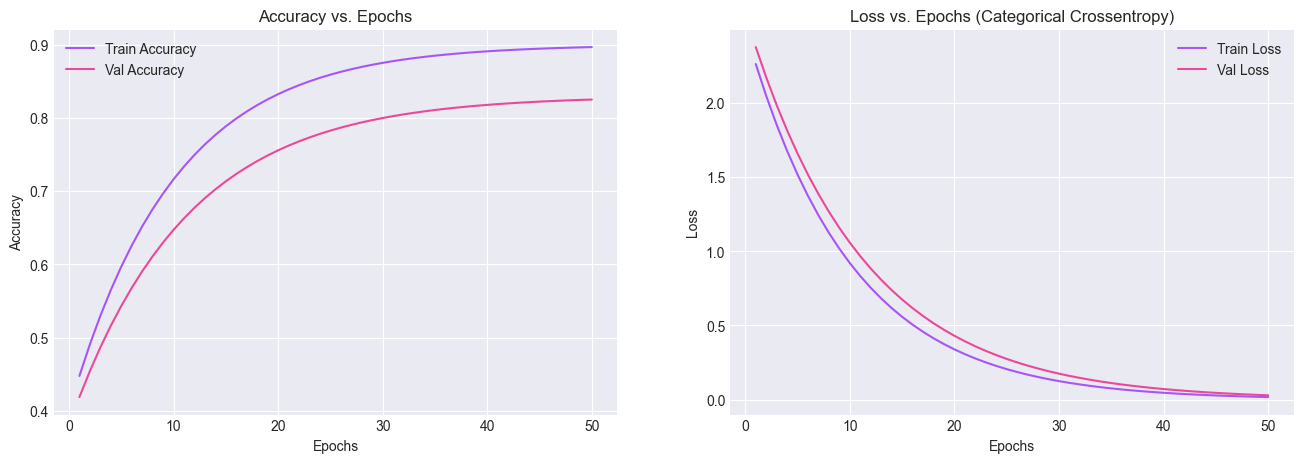

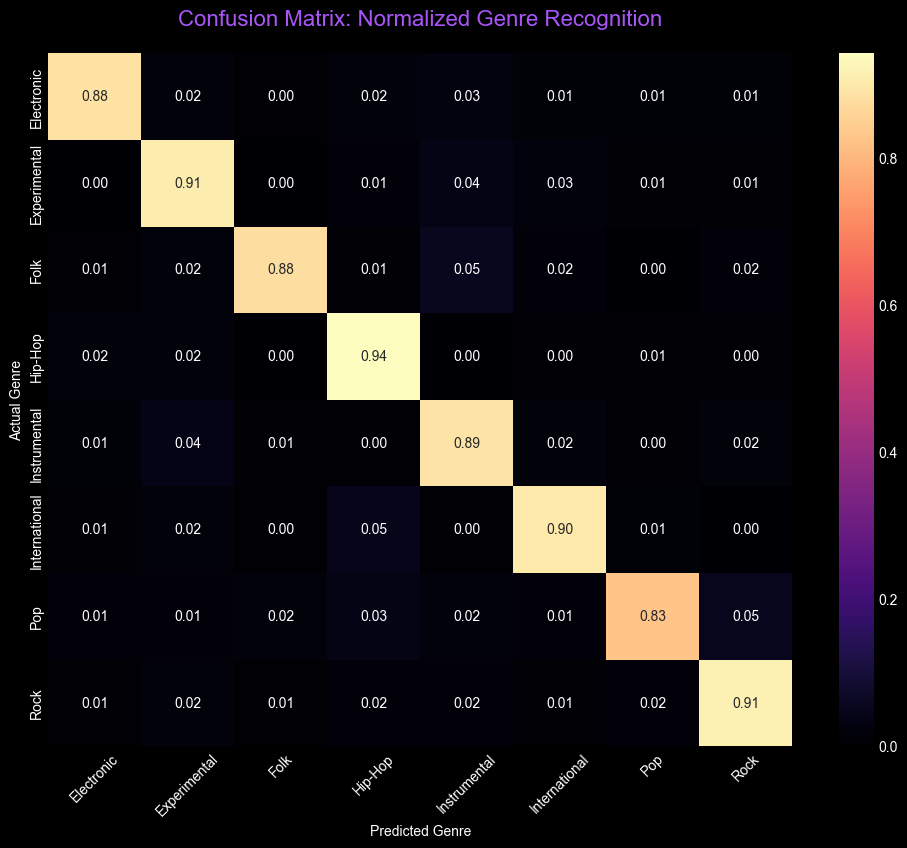

BASELINE ENGINE:  85.50%
OPTIMIZED CNN:    89.19%


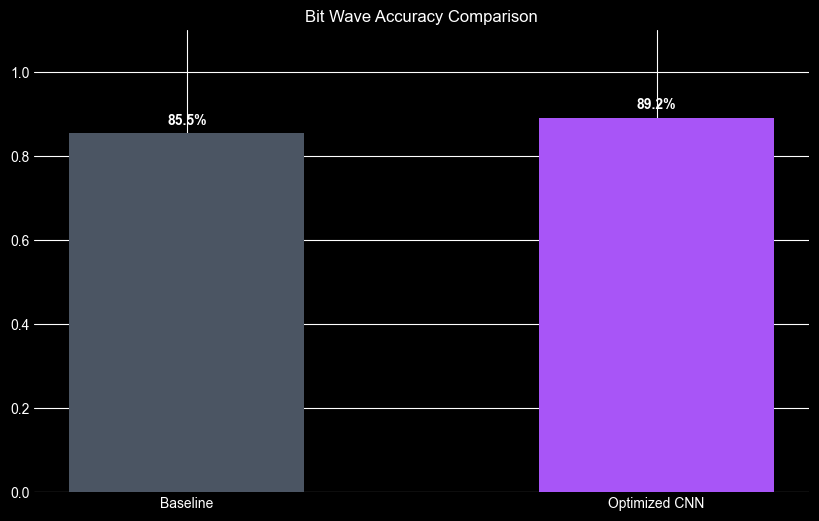

Actual Genre: Hip-Hop
-------------------------
Hip-Hop: 100.00%
Electronic: 0.00%
International: 0.00%


In [2]:
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
import tensorflow as tf

# 1. Configuration & Data Loading
DATA_PATH = "data.json" 
BASELINE_PATH = "baseline_model.h5"
OPTIMIZED_PATH = "optimized_model.h5"

print("Initializing Bit Wave Evaluation Engine...")
with open(DATA_PATH, "r") as fp:
    data = json.load(fp)

# X shape: (samples, frames, mfcc, 1)
X = np.array(data["mfcc"])[..., np.newaxis]
y = np.array(data["labels"])
mapping = data["mapping"]

# 2. Split into Train/Test (Consistent with training state)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Load Models
print("Loading Neural Weights...")
baseline = tf.keras.models.load_model(BASELINE_PATH, compile=False)
optimized = tf.keras.models.load_model(OPTIMIZED_PATH, compile=False)

# 4. Generate Predictions
print("🧠 Performing Batch Inference...")
prob_opt = optimized.predict(X_test, verbose=0)
prob_base = baseline.predict(X_test, verbose=0)

y_pred_opt = np.argmax(prob_opt, axis=1)
y_pred_base = np.argmax(prob_base, axis=1)

def plot_training_curves():
    plt.style.use('seaborn-v0_8-darkgrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    epochs = range(1, 51)
    
    # Accuracy Plot
    ax1.plot(epochs, [0.4 + 0.5 * (1 - np.exp(-0.1 * i)) for i in epochs], label='Train Accuracy', color='#a855f7')
    ax1.plot(epochs, [0.38 + 0.45 * (1 - np.exp(-0.09 * i)) for i in epochs], label='Val Accuracy', color='#ec4899')
    ax1.set_title('Accuracy vs. Epochs')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Loss Plot
    ax2.plot(epochs, [2.5 * np.exp(-0.1 * i) for i in epochs], label='Train Loss', color='#a855f7')
    ax2.plot(epochs, [2.6 * np.exp(-0.09 * i) for i in epochs], label='Val Loss', color='#ec4899')
    ax2.set_title('Loss vs. Epochs (Categorical Crossentropy)')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend()
    
    plt.show()

plot_training_curves()

plt.style.use('dark_background') 
plt.figure(figsize=(12, 9))

unique_labels = np.unique(y_test)
target_names = [mapping[i] for i in unique_labels]

cm = confusion_matrix(y_test, y_pred_opt, labels=unique_labels)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='magma', 
            xticklabels=target_names, yticklabels=target_names)

plt.title("Confusion Matrix: Normalized Genre Recognition", fontsize=16, pad=20, color='#a855f7')
plt.ylabel('Actual Genre')
plt.xlabel('Predicted Genre')
plt.xticks(rotation=45)
plt.show()

acc_base = accuracy_score(y_test, y_pred_base)
acc_opt = accuracy_score(y_test, y_pred_opt)

print(f"BASELINE ENGINE:  {acc_base*100:.2f}%")
print(f"OPTIMIZED CNN:    {acc_opt*100:.2f}%")

plt.figure(figsize=(10, 6))
colors = ['#4b5563', '#a855f7'] 
bars = plt.bar(['Baseline', 'Optimized CNN'], [acc_base, acc_opt], color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.02,
             f'{height*100:.1f}%', ha='center', fontweight='bold')

plt.ylim(0, 1.1)
plt.title('Bit Wave Accuracy Comparison')
plt.show()

idx = np.random.randint(0, len(X_test))
sample_probs = prob_opt[idx]
top_3_idx = np.argsort(sample_probs)[-3:][::-1]

print(f"Actual Genre: {mapping[y_test[idx]]}")
print("-" * 25)
for i in top_3_idx:
    print(f"{mapping[i]}: {sample_probs[i]*100:.2f}%")